In [6]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..")))

### 그리드서치

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    log_loss, confusion_matrix, precision_recall_curve
)

from data.preprocessing_code import get_hr_data


RANDOM_STATE = 42
DATA_PATH = "../data/data_team7.csv"


def evaluate_binary_model(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Threshold": round(threshold, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "LogLoss": round(log_loss(y_true, y_prob), 4),
        "ConfusionMatrix": confusion_matrix(y_true, y_pred)
    }


def find_best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # thresholds는 precisions/recalls보다 길이가 1 작음
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

def run_lgbm_gridsearch():
    print("1. 데이터 로드 및 공통 전처리 함수 적용")

    X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(
        DATA_PATH,
        model_type="lgbm_tabnet"
    )

    y_train = y_train.replace({"Yes": 1, "No": 0}).astype(int)
    y_valid = y_valid.replace({"Yes": 1, "No": 0}).astype(int)
    y_test = y_test.replace({"Yes": 1, "No": 0}).astype(int)

    numerical_cols = [
        "Age", "DailyRate", "DistanceFromHome", "Education",
        "EnvironmentSatisfaction", "HourlyRate", "JobInvolvement",
        "JobLevel", "JobSatisfaction", "MonthlyIncome", "MonthlyRate",
        "PercentSalaryHike", "PerformanceRating",
        "RelationshipSatisfaction", "StockOptionLevel",
        "TotalWorkingYears", "TrainingTimesLastYear", "WorkLifeBalance",
        "YearsAtCompany", "YearsInCurrentRole",
        "YearsSinceLastPromotion", "YearsWithCurrManager"
    ]

    categorical_cols = [
        "BusinessTravel", "Department", "EducationField",
        "Gender", "JobRole", "MaritalStatus", "OverTime"
    ]

    all_cols = numerical_cols + categorical_cols

    X_train_df = pd.DataFrame(X_train, columns=all_cols)
    X_valid_df = pd.DataFrame(X_valid, columns=all_cols)
    X_test_df = pd.DataFrame(X_test, columns=all_cols)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    base_model = lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        min_child_samples=10,
        verbose=-1
    )

    param_grid = {
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "num_leaves": [7, 15, 31],
        "reg_alpha": [0, 0.1, 1],
        "reg_lambda": [0, 0.1, 1]
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    print("2. GridSearchCV 실행: 기준 지표 = PR-AUC")
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid_search.fit(X_train_df, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(grid_search.best_params_)
    print(f"CV Best PR-AUC: {grid_search.best_score_:.4f}")

    tuning_results = pd.DataFrame(grid_search.cv_results_)
    tuning_results = tuning_results[
        [
            "rank_test_score", "mean_test_score", "std_test_score",
            "param_learning_rate", "param_max_depth", "param_num_leaves",
            "param_reg_alpha", "param_reg_lambda"
        ]
    ].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(
        "../results/lgbm_grid_tuning_results.csv",
        index=False,
        encoding="utf-8-sig"
    )

    best_model = grid_search.best_estimator_

    print("\n4. Validation set에서 F1이 최대가 되는 threshold 선택")
    y_valid_prob = best_model.predict_proba(X_valid_df)[:, 1]
    best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Validation best F1: {best_valid_f1:.4f}")

    valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)

    print("\n5. Test set 최종 평가")
    y_test_prob = best_model.predict_proba(X_test_df)[:, 1]
    test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

    summary_df = pd.DataFrame([
        {
            "Dataset": "Validation",
            "Model": "LightGBM",
            "Search Method": "GridSearchCV",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in valid_result.items() if k != "ConfusionMatrix"}
        },
        {
            "Dataset": "Test",
            "Model": "LightGBM",
            "Search Method": "GridSearchCV",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in test_result.items() if k != "ConfusionMatrix"}
        }
    ])

    display(summary_df)

    print("\n[Validation Confusion Matrix]")
    print(valid_result["ConfusionMatrix"])

    print("\n[Test Confusion Matrix]")
    print(test_result["ConfusionMatrix"])

    summary_df.to_csv(
        "../results/lgbm_grid_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    return best_model, grid_search, summary_df


grid_lgbm, grid_search, grid_summary = run_lgbm_gridsearch()

1. 데이터 로드 및 공통 전처리 함수 적용
scale_pos_weight: 5.1988
2. GridSearchCV 실행: 기준 지표 = PR-AUC
Fitting 3 folds for each of 243 candidates, totalling 729 fits

3. 최적 하이퍼파라미터
{'learning_rate': 0.2, 'max_depth': 5, 'num_leaves': 7, 'reg_alpha': 1, 'reg_lambda': 1}
CV Best PR-AUC: 0.5988


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_reg_alpha,param_reg_lambda
197,1,0.598805,0.007746,0.2,5,7,1.0,1.0
218,2,0.594467,0.010587,0.2,7,7,0.0,1.0
194,3,0.590630,0.039709,0.2,5,7,0.1,1.0
221,4,0.589242,0.019000,0.2,7,7,0.1,1.0
116,5,0.588362,0.025077,0.1,5,7,1.0,1.0
202,6,0.587375,0.005281,0.2,5,15,0.1,0.1
151,7,0.587013,0.004037,0.1,7,15,1.0,0.1
195,8,0.585514,0.017274,0.2,5,7,1.0,0.0
142,9,0.585396,0.007381,0.1,7,7,1.0,0.1
112,10,0.585286,0.023384,0.1,5,7,0.1,0.1



4. Validation set에서 F1이 최대가 되는 threshold 선택
Best threshold: 0.1941
Validation best F1: 0.4324

5. Test set 최종 평가


,Dataset,Model,Search Method,Selection Metric,Threshold,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,LogLoss
0,Validation,LightGBM,GridSearchCV,PR-AUC,0.1941,0.3158,0.6857,0.4324,0.7050,0.3630,0.4562
1,Test,LightGBM,GridSearchCV,PR-AUC,0.1941,0.3293,0.7500,0.4576,0.7899,0.5125,0.3901



[Validation Confusion Matrix]
[[133  52]
 [ 11  24]]

[Test Confusion Matrix]
[[130  55]
 [  9  27]]


### 랜덤서치

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    log_loss, confusion_matrix, precision_recall_curve
)

from data.preprocessing_code import get_hr_data


RANDOM_STATE = 42
DATA_PATH = "../data/data_team7.csv"


def evaluate_binary_model(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Threshold": round(threshold, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "LogLoss": round(log_loss(y_true, y_prob), 4),
        "ConfusionMatrix": confusion_matrix(y_true, y_pred)
    }


def find_best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # thresholds는 precisions/recalls보다 길이가 1 작음
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def run_lgbm_randomsearch():
    print("1. 데이터 로드 및 공통 전처리 함수 적용")

    X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(
        DATA_PATH,
        model_type="lgbm_tabnet"
    )

    y_train = y_train.replace({"Yes": 1, "No": 0}).astype(int)
    y_valid = y_valid.replace({"Yes": 1, "No": 0}).astype(int)
    y_test = y_test.replace({"Yes": 1, "No": 0}).astype(int)

    numerical_cols = [
        "Age", "DailyRate", "DistanceFromHome", "Education",
        "EnvironmentSatisfaction", "HourlyRate", "JobInvolvement",
        "JobLevel", "JobSatisfaction", "MonthlyIncome", "MonthlyRate",
        "PercentSalaryHike", "PerformanceRating",
        "RelationshipSatisfaction", "StockOptionLevel",
        "TotalWorkingYears", "TrainingTimesLastYear", "WorkLifeBalance",
        "YearsAtCompany", "YearsInCurrentRole",
        "YearsSinceLastPromotion", "YearsWithCurrManager"
    ]

    categorical_cols = [
        "BusinessTravel", "Department", "EducationField",
        "Gender", "JobRole", "MaritalStatus", "OverTime"
    ]

    all_cols = numerical_cols + categorical_cols

    X_train_df = pd.DataFrame(X_train, columns=all_cols)
    X_valid_df = pd.DataFrame(X_valid, columns=all_cols)
    X_test_df = pd.DataFrame(X_test, columns=all_cols)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    base_model = lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        min_child_samples=10,
        verbose=-1
    )

    param_distributions = {
        "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7, 9, -1],
        "num_leaves": [7, 15, 31, 63, 127],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

        # LightGBM의 L1/L2 규제
        "reg_alpha": [0, 0.01, 0.1, 1, 5],
        "reg_lambda": [0, 0.01, 0.1, 1, 5]
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    print("2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC")
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=50,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    random_search.fit(X_train_df, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(random_search.best_params_)
    print(f"CV Best PR-AUC: {random_search.best_score_:.4f}")

    tuning_results = pd.DataFrame(random_search.cv_results_)
    tuning_results = tuning_results[
        [
            "rank_test_score", "mean_test_score", "std_test_score",
            "param_learning_rate", "param_max_depth", "param_num_leaves",
            "param_subsample", "param_colsample_bytree",
            "param_reg_alpha", "param_reg_lambda"
        ]
    ].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(
        "../results/lgbm_random_tuning_results.csv",
        index=False,
        encoding="utf-8-sig"
    )

    best_model = random_search.best_estimator_

    print("\n4. Validation set에서 F1이 최대가 되는 threshold 선택")
    y_valid_prob = best_model.predict_proba(X_valid_df)[:, 1]
    best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Validation best F1: {best_valid_f1:.4f}")

    valid_result = evaluate_binary_model(
        y_valid,
        y_valid_prob,
        best_threshold
    )

    print("\n5. Test set 최종 평가")
    y_test_prob = best_model.predict_proba(X_test_df)[:, 1]

    test_result = evaluate_binary_model(
        y_test,
        y_test_prob,
        best_threshold
    )

    summary_df = pd.DataFrame([
        {
            "Dataset": "Validation",
            "Model": "LightGBM",
            "Search Method": "RandomizedSearchCV",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in valid_result.items() if k != "ConfusionMatrix"}
        },
        {
            "Dataset": "Test",
            "Model": "LightGBM",
            "Search Method": "RandomizedSearchCV",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in test_result.items() if k != "ConfusionMatrix"}
        }
    ])

    display(summary_df)

    print("\n[Validation Confusion Matrix]")
    print(valid_result["ConfusionMatrix"])

    print("\n[Test Confusion Matrix]")
    print(test_result["ConfusionMatrix"])

    summary_df.to_csv(
        "../results/lgbm_random_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    return best_model, random_search, summary_df


best_lgbm, lgbm_search, lgbm_summary = run_lgbm_randomsearch()

1. 데이터 로드 및 공통 전처리 함수 적용
scale_pos_weight: 5.1988
2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC
Fitting 3 folds for each of 50 candidates, totalling 150 fits

3. 최적 하이퍼파라미터
{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 7, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
CV Best PR-AUC: 0.6162


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda
48,1,0.616213,0.024961,0.20,7,7,0.7,0.7,0.00,5.00
43,2,0.589333,0.025501,0.10,7,31,0.7,0.7,5.00,1.00
7,3,0.586168,0.007378,0.20,-1,15,0.9,0.9,5.00,1.00
34,4,0.585306,0.032190,0.05,9,7,1.0,0.9,0.10,0.10
8,5,0.583023,0.012325,0.10,9,127,0.9,0.8,1.00,0.00
5,6,0.581238,0.015311,0.05,7,31,0.8,0.7,1.00,0.01
22,7,0.579700,0.025201,0.05,7,63,0.7,0.7,5.00,5.00
9,8,0.577561,0.017219,0.10,-1,15,1.0,1.0,5.00,0.10
42,9,0.577415,0.031583,0.20,5,15,1.0,0.7,0.01,0.01
35,10,0.576909,0.022402,0.20,7,63,0.9,0.7,5.00,1.00



4. Validation set에서 F1이 최대가 되는 threshold 선택
Best threshold: 0.3575
Validation best F1: 0.4691

5. Test set 최종 평가


,Dataset,Model,Search Method,Selection Metric,Threshold,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,LogLoss
0,Validation,LightGBM,RandomizedSearchCV,PR-AUC,0.3575,0.413,0.5429,0.4691,0.7185,0.3813,0.4413
1,Test,LightGBM,RandomizedSearchCV,PR-AUC,0.3575,0.386,0.6111,0.4731,0.7853,0.4978,0.4017



[Validation Confusion Matrix]
[[158  27]
 [ 16  19]]

[Test Confusion Matrix]
[[150  35]
 [ 14  22]]


### optuna

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    log_loss, confusion_matrix, precision_recall_curve
)

from data.preprocessing_code import get_hr_data


RANDOM_STATE = 42
DATA_PATH = "../data/data_team7.csv"


def evaluate_binary_model(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Threshold": round(threshold, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "LogLoss": round(log_loss(y_true, y_prob), 4),
        "ConfusionMatrix": confusion_matrix(y_true, y_pred)
    }


def find_best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # thresholds는 precisions/recalls보다 길이가 1 작음
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def run_lgbm_optuna():
    print("1. 데이터 로드 및 공통 전처리 함수 적용")

    X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(
        DATA_PATH,
        model_type="lgbm_tabnet"
    )

    y_train = y_train.replace({"Yes": 1, "No": 0}).astype(int)
    y_valid = y_valid.replace({"Yes": 1, "No": 0}).astype(int)
    y_test = y_test.replace({"Yes": 1, "No": 0}).astype(int)

    numerical_cols = [
        "Age", "DailyRate", "DistanceFromHome", "Education",
        "EnvironmentSatisfaction", "HourlyRate", "JobInvolvement",
        "JobLevel", "JobSatisfaction", "MonthlyIncome", "MonthlyRate",
        "PercentSalaryHike", "PerformanceRating",
        "RelationshipSatisfaction", "StockOptionLevel",
        "TotalWorkingYears", "TrainingTimesLastYear", "WorkLifeBalance",
        "YearsAtCompany", "YearsInCurrentRole",
        "YearsSinceLastPromotion", "YearsWithCurrManager"
    ]

    categorical_cols = [
        "BusinessTravel", "Department", "EducationField",
        "Gender", "JobRole", "MaritalStatus", "OverTime"
    ]

    all_cols = numerical_cols + categorical_cols

    X_train_df = pd.DataFrame(X_train, columns=all_cols)
    X_valid_df = pd.DataFrame(X_valid, columns=all_cols)
    X_test_df = pd.DataFrame(X_test, columns=all_cols)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    def objective(trial):
        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,

            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 9),
            "num_leaves": trial.suggest_int("num_leaves", 7, 127),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

            # LightGBM의 L1/L2 규제
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0)
        }

        pr_auc_scores = []

        for train_idx, val_idx in cv.split(X_train_df, y_train):
            X_tr = X_train_df.iloc[train_idx]
            X_va = X_train_df.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_va = y_train.iloc[val_idx]

            model = lgb.LGBMClassifier(**params)
            model.fit(X_tr, y_tr)

            y_va_prob = model.predict_proba(X_va)[:, 1]
            pr_auc_scores.append(average_precision_score(y_va, y_va_prob))

        return np.mean(pr_auc_scores)

    print("2. Optuna 실행: 기준 지표 = PR-AUC")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(
        direction="maximize",
        study_name="LGBM_Optuna_Regularization"
    )

    study.optimize(objective, n_trials=50)

    print("\n3. 최적 하이퍼파라미터")
    print(study.best_params)
    print(f"CV Best PR-AUC: {study.best_value:.4f}")

    best_params = {
        **study.best_params,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators": 100,
        "min_child_samples": 10,
        "verbose": -1
    }

    best_model = lgb.LGBMClassifier(**best_params)
    best_model.fit(X_train_df, y_train)

    print("\n4. Validation set에서 F1이 최대가 되는 threshold 선택")
    y_valid_prob = best_model.predict_proba(X_valid_df)[:, 1]
    best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Validation best F1: {best_valid_f1:.4f}")

    valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)

    print("\n5. Test set 최종 평가")
    y_test_prob = best_model.predict_proba(X_test_df)[:, 1]
    test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

    summary_df = pd.DataFrame([
        {
            "Dataset": "Validation",
            "Model": "LightGBM",
            "Search Method": "Optuna",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in valid_result.items() if k != "ConfusionMatrix"}
        },
        {
            "Dataset": "Test",
            "Model": "LightGBM",
            "Search Method": "Optuna",
            "Selection Metric": "PR-AUC",
            **{k: v for k, v in test_result.items() if k != "ConfusionMatrix"}
        }
    ])

    display(summary_df)

    print("\n[Validation Confusion Matrix]")
    print(valid_result["ConfusionMatrix"])

    print("\n[Test Confusion Matrix]")
    print(test_result["ConfusionMatrix"])

    summary_df.to_csv(
        "../results/lgbm_optuna_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    trials_df = study.trials_dataframe()
    trials_df.to_csv(
        "../results/lgbm_optuna_tuning_results.csv",
        index=False,
        encoding="utf-8-sig"
    )

    return best_model, study, summary_df


optuna_lgbm, optuna_study, optuna_summary = run_lgbm_optuna()

c:\Users\sonju\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. 데이터 로드 및 공통 전처리 함수 적용
scale_pos_weight: 5.1988
2. Optuna 실행: 기준 지표 = PR-AUC

3. 최적 하이퍼파라미터
{'learning_rate': 0.1970320438564945, 'max_depth': 5, 'num_leaves': 7, 'subsample': 0.8393117743936486, 'colsample_bytree': 0.7621713148153292, 'reg_alpha': 4.695733522956783, 'reg_lambda': 1.6295552621718652}
CV Best PR-AUC: 0.6054

4. Validation set에서 F1이 최대가 되는 threshold 선택
Best threshold: 0.3829
Validation best F1: 0.4186

5. Test set 최종 평가


,Dataset,Model,Search Method,Selection Metric,Threshold,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,LogLoss
0,Validation,LightGBM,Optuna,PR-AUC,0.3829,0.3529,0.5143,0.4186,0.7154,0.3812,0.4518
1,Test,LightGBM,Optuna,PR-AUC,0.3829,0.3667,0.6111,0.4583,0.7938,0.5169,0.4071



[Validation Confusion Matrix]
[[152  33]
 [ 17  18]]

[Test Confusion Matrix]
[[147  38]
 [ 14  22]]


### LGBM 성능 실험

### LGBM 최종 학습 실험 및 시각화

최적 파라미터를 모아 같은 기준으로 모델을 학습. 
Validation set에서 F1이 최대가 되는 threshold를 선택하고, Test set에서 최종 성능과 시각화 결과를 저장



===== grid_search 최종 학습 시작 =====


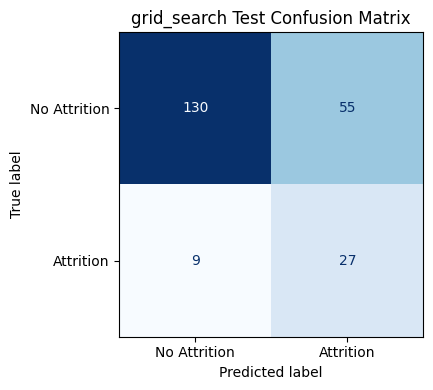

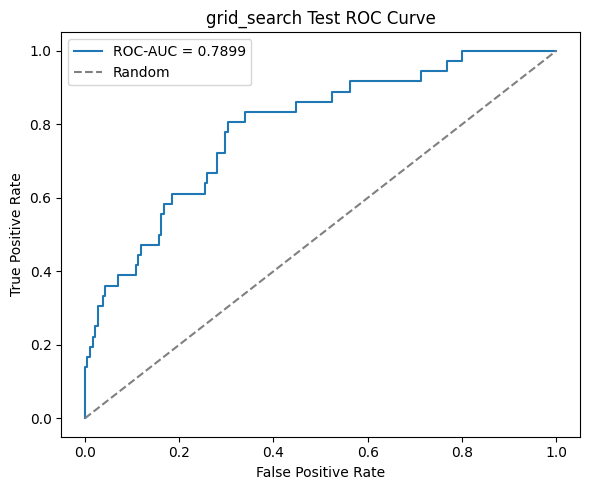

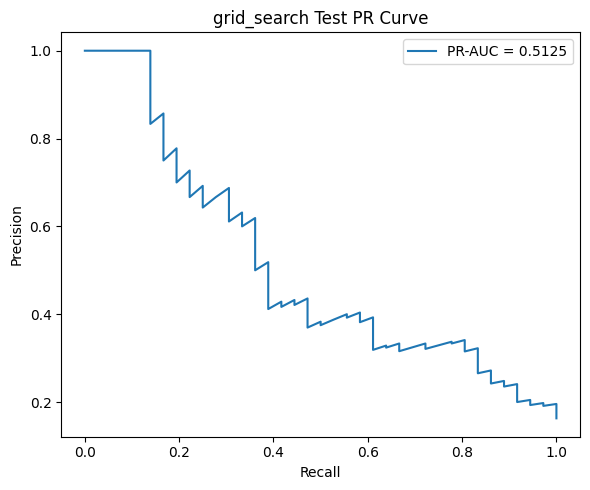

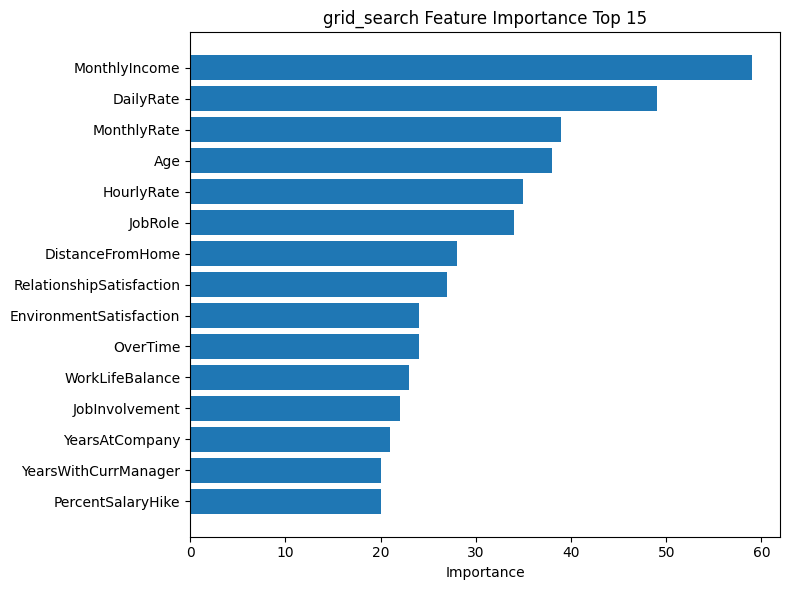

Best threshold: 0.1941
Validation F1: 0.4324
Test F1: 0.4576
Test PR-AUC: 0.5125
Top 5 features:


,Feature,Importance
9,MonthlyIncome,59
1,DailyRate,49
10,MonthlyRate,39
0,Age,38
5,HourlyRate,35



===== random_search 최종 학습 시작 =====


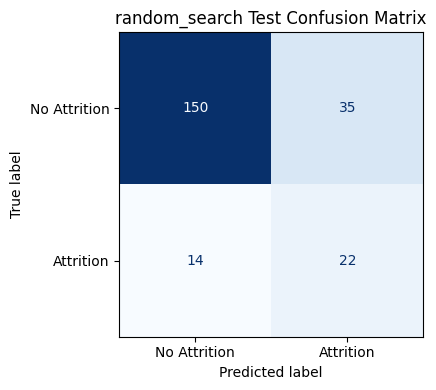

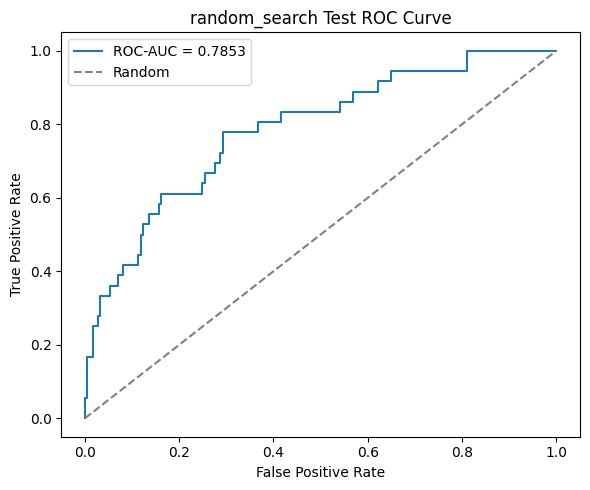

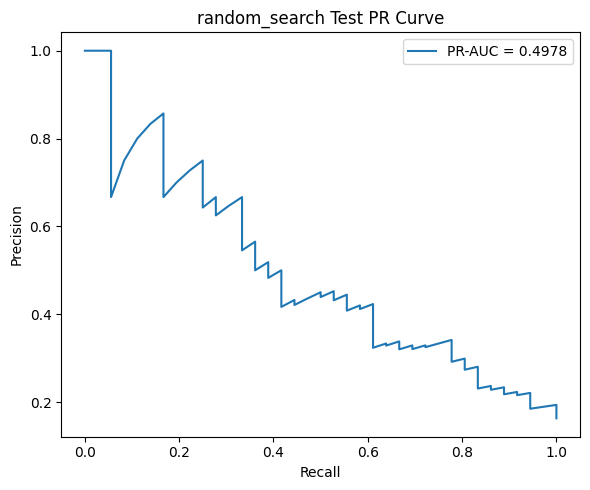

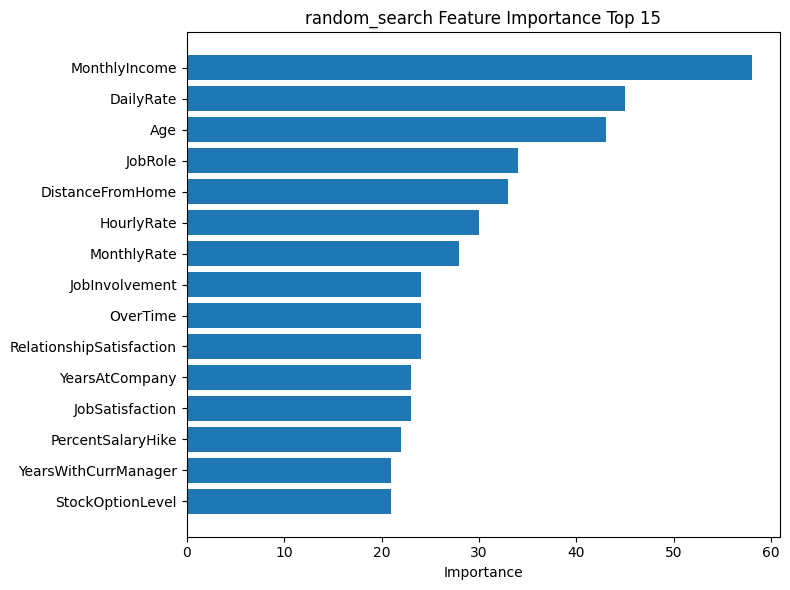

Best threshold: 0.3575
Validation F1: 0.4691
Test F1: 0.4731
Test PR-AUC: 0.4978
Top 5 features:


,Feature,Importance
9,MonthlyIncome,58
1,DailyRate,45
0,Age,43
26,JobRole,34
2,DistanceFromHome,33



===== optuna 최종 학습 시작 =====


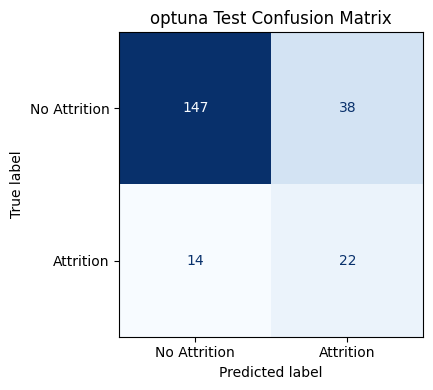

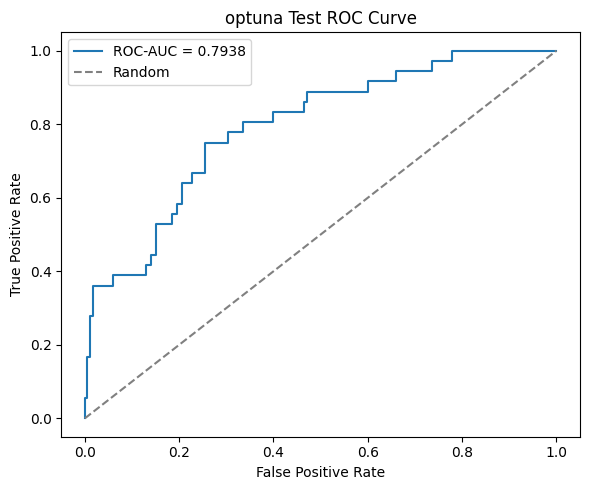

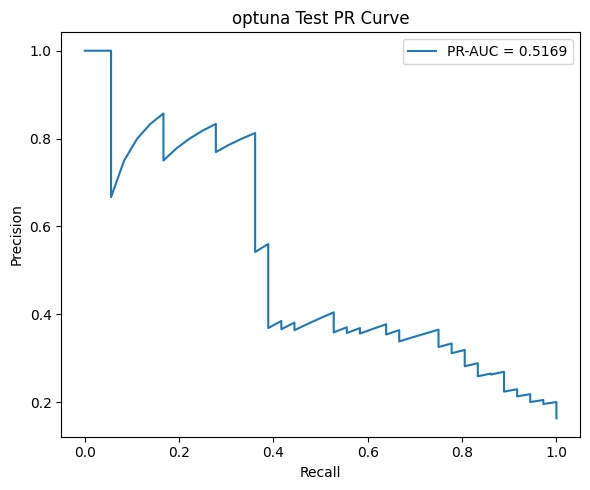

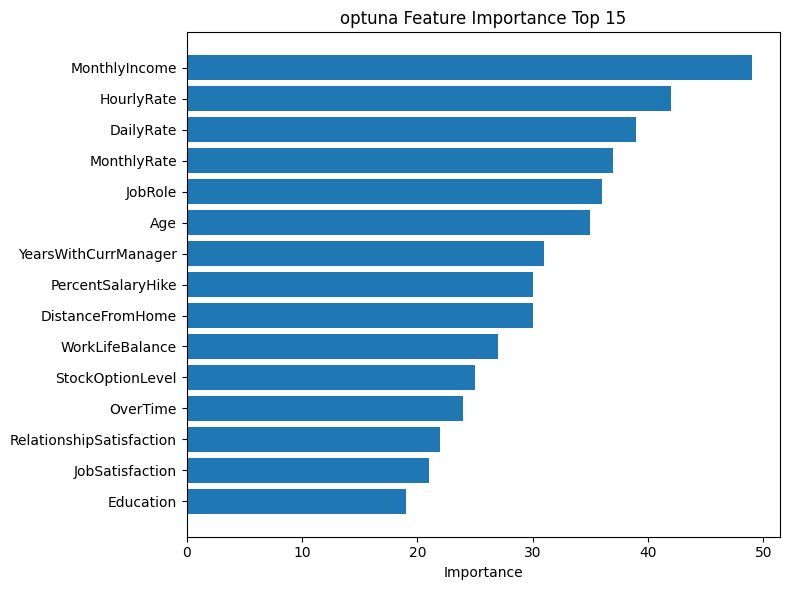

Best threshold: 0.3829
Validation F1: 0.4186
Test F1: 0.4583
Test PR-AUC: 0.5169
Top 5 features:


,Feature,Importance
9,MonthlyIncome,49
5,HourlyRate,42
1,DailyRate,39
10,MonthlyRate,37
26,JobRole,36



===== LGBM 최종 실험 요약 =====


,Attempt,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,LogLoss
0,grid_search,GridSearchCV,Validation,0.5988,0.1941,0.3158,0.6857,0.4324,0.7050,0.3630,0.4562
1,grid_search,GridSearchCV,Test,0.5988,0.1941,0.3293,0.7500,0.4576,0.7899,0.5125,0.3901
2,random_search,RandomizedSearchCV,Validation,0.6162,0.3575,0.4130,0.5429,0.4691,0.7185,0.3813,0.4413
3,random_search,RandomizedSearchCV,Test,0.6162,0.3575,0.3860,0.6111,0.4731,0.7853,0.4978,0.4017
4,optuna,Optuna,Validation,0.6054,0.3829,0.3529,0.5143,0.4186,0.7154,0.3812,0.4518
5,optuna,Optuna,Test,0.6054,0.3829,0.3667,0.6111,0.4583,0.7938,0.5169,0.4071



결과 저장 위치: ..\results\lgbm_experiments


In [15]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

# 시각화 결과와 최종 실험 결과를 저장할 폴더입니다.
# 노트북 위치가 Team-7/models 이므로, ../results 아래에 저장합니다.
EXPERIMENT_DIR = Path("../results/lgbm_experiments")
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)


# 팀장님 공통 전처리 함수의 반환값은 numpy array이므로,
# 피처 중요도 시각화를 위해 컬럼명을 다시 붙여줍니다.
NUMERICAL_COLS = [
    "Age", "DailyRate", "DistanceFromHome", "Education",
    "EnvironmentSatisfaction", "HourlyRate", "JobInvolvement",
    "JobLevel", "JobSatisfaction", "MonthlyIncome", "MonthlyRate",
    "PercentSalaryHike", "PerformanceRating",
    "RelationshipSatisfaction", "StockOptionLevel",
    "TotalWorkingYears", "TrainingTimesLastYear", "WorkLifeBalance",
    "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager"
]

CATEGORICAL_COLS = [
    "BusinessTravel", "Department", "EducationField",
    "Gender", "JobRole", "MaritalStatus", "OverTime"
]

FEATURE_NAMES = NUMERICAL_COLS + CATEGORICAL_COLS


def load_lgbm_data_as_dataframe():
    """공통 전처리 함수를 호출한 뒤 LGBM 실험용 DataFrame으로 변환합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(
        DATA_PATH,
        model_type="lgbm_tabnet"
    )

    y_train = y_train.replace({"Yes": 1, "No": 0}).astype(int)
    y_valid = y_valid.replace({"Yes": 1, "No": 0}).astype(int)
    y_test = y_test.replace({"Yes": 1, "No": 0}).astype(int)

    X_train = pd.DataFrame(X_train, columns=FEATURE_NAMES)
    X_valid = pd.DataFrame(X_valid, columns=FEATURE_NAMES)
    X_test = pd.DataFrame(X_test, columns=FEATURE_NAMES)

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def save_confusion_matrix_plot(y_true, y_prob, threshold, save_path, title):
    """선택된 threshold 기준의 confusion matrix를 이미지로 저장합니다."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Attrition", "Attrition"]
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_roc_curve_plot(y_true, y_prob, save_path, title):
    """ROC curve를 그리고 ROC-AUC 값을 함께 표시합니다."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_pr_curve_plot(y_true, y_prob, save_path, title):
    """PR curve를 그리고 PR-AUC 값을 함께 표시합니다."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_feature_importance_plot(model, save_csv_path, save_png_path, title):
    """LightGBM feature importance를 CSV와 Top 15 막대그래프로 저장합니다."""
    importance_df = pd.DataFrame({
        "Feature": FEATURE_NAMES,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    importance_df.to_csv(save_csv_path, index=False, encoding="utf-8-sig")

    top_df = importance_df.head(15).sort_values("Importance")

    plt.figure(figsize=(8, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_png_path, dpi=150)
    plt.show()
    plt.close()

    return importance_df


def build_attempts_from_tuning_results():
    """앞선 튜닝 결과 객체에서 각 방식의 최적 파라미터를 모읍니다."""
    attempts = []

    if "grid_search" in globals():
        attempts.append({
            "Attempt": "grid_search",
            "Search Method": "GridSearchCV",
            "CV Best PR-AUC": grid_search.best_score_,
            "Params": grid_search.best_params_
        })

    if "lgbm_search" in globals():
        attempts.append({
            "Attempt": "random_search",
            "Search Method": "RandomizedSearchCV",
            "CV Best PR-AUC": lgbm_search.best_score_,
            "Params": lgbm_search.best_params_
        })

    if "optuna_study" in globals():
        attempts.append({
            "Attempt": "optuna",
            "Search Method": "Optuna",
            "CV Best PR-AUC": optuna_study.best_value,
            "Params": optuna_study.best_params
        })

    if not attempts:
        raise RuntimeError(
            "튜닝 결과 객체를 찾지 못했습니다. "
            "위쪽의 GridSearch/RandomizedSearch/Optuna 셀을 먼저 실행해주세요."
        )

    return attempts


def run_final_lgbm_experiments():
    """세 튜닝 방식의 최적 파라미터로 모델을 학습하고 결과와 시각화를 저장합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test = load_lgbm_data_as_dataframe()
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    attempts = build_attempts_from_tuning_results()

    all_results = []

    for attempt in attempts:
        attempt_name = attempt["Attempt"]
        search_method = attempt["Search Method"]
        attempt_dir = EXPERIMENT_DIR / attempt_name
        attempt_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {attempt_name} 최종 학습 시작 =====")

        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,
            **attempt["Params"]
        }

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)

        # Validation set에서 F1이 가장 높은 threshold를 찾습니다.
        y_valid_prob = model.predict_proba(X_valid)[:, 1]
        best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

        # 선택된 threshold는 고정하고, Test set에서 최종 성능을 평가합니다.
        y_test_prob = model.predict_proba(X_test)[:, 1]
        valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)
        test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

        for dataset_name, result in [("Validation", valid_result), ("Test", test_result)]:
            all_results.append({
                "Attempt": attempt_name,
                "Search Method": search_method,
                "Dataset": dataset_name,
                "CV Best PR-AUC": round(attempt["CV Best PR-AUC"], 4),
                **{k: v for k, v in result.items() if k != "ConfusionMatrix"}
            })

        # 재현성을 위해 최종 파라미터와 학습된 모델을 함께 저장합니다.
        with open(attempt_dir / "params.json", "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4, ensure_ascii=False)

        joblib.dump(model, attempt_dir / "model.joblib")

        save_confusion_matrix_plot(
            y_test,
            y_test_prob,
            best_threshold,
            attempt_dir / "test_confusion_matrix.png",
            f"{attempt_name} Test Confusion Matrix"
        )

        save_roc_curve_plot(
            y_test,
            y_test_prob,
            attempt_dir / "test_roc_curve.png",
            f"{attempt_name} Test ROC Curve"
        )

        save_pr_curve_plot(
            y_test,
            y_test_prob,
            attempt_dir / "test_pr_curve.png",
            f"{attempt_name} Test PR Curve"
        )

        importance_df = save_feature_importance_plot(
            model,
            attempt_dir / "feature_importance.csv",
            attempt_dir / "feature_importance_top15.png",
            f"{attempt_name} Feature Importance Top 15"
        )

        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Validation F1: {valid_result['F1-Score']:.4f}")
        print(f"Test F1: {test_result['F1-Score']:.4f}")
        print(f"Test PR-AUC: {test_result['PR-AUC']:.4f}")
        print("Top 5 features:")
        display(importance_df.head(5))

    results_df = pd.DataFrame(all_results)
    results_df.to_csv(
        EXPERIMENT_DIR / "lgbm_final_experiment_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\n===== LGBM 최종 실험 요약 =====")
    display(results_df)
    print(f"\n결과 저장 위치: {EXPERIMENT_DIR}")

    return results_df


lgbm_final_summary = run_final_lgbm_experiments()
